# CSE-CIC-IDS2018 — Model Training with Optuna

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies.

Instead of hand-picking one algorithm and guessing hyperparameters, this notebook:

1. Defines a **single Optuna search space** covering 5 algorithms: Decision Tree, Random Forest,
   Histogram Gradient Boosting, XGBoost, and AdaBoost — Optuna picks both the algorithm *and*
   its hyperparameters per trial.
2. Runs the search on a **stratified subsample** of the training set (fast iteration), scoring
   trials with cross-validated **macro F1** (appropriate for this imbalanced, multi-class problem).
3. Selects the **3 best-performing algorithms** found during the search.
4. Retrains each of those 3 with its best hyperparameters on the **full** balanced training set,
   evaluates on the held-out test set, and saves models + metrics + confusion matrices.

> Requires: `pip install optuna xgboost`

> Note on Gradient Boosting: this notebook uses scikit-learn's `HistGradientBoostingClassifier`
> rather than the classic `GradientBoostingClassifier`. It is the modern, histogram-based
> implementation of the same algorithm family (comparable to LightGBM/XGBoost in speed) and is
> dramatically faster on datasets of this size — the classic version would be impractically slow
> to tune with Optuna on hundreds of thousands of rows.

## 1. Configuration & Setup

In [20]:
import os
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [21]:
PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH   = PROJECT_PATH / "Results"
MODELS_PATH    = RESULTS_PATH / "Models"
FIGURES_PATH   = RESULTS_PATH / "Figures"
TABLES_PATH    = RESULTS_PATH / "Tables"

for p in [MODELS_PATH, FIGURES_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 3
N_TRIALS = 60          # increase for a more thorough search
HPO_SAMPLE_SIZE = 100_000   # rows used for the Optuna search (full data used for final training)

## 2. Load Data

In [22]:
train = pd.read_parquet(PROCESSED_DATA_PATH / "balanced_train_selected.parquet")
test = pd.read_parquet(PROCESSED_DATA_PATH / "test_selected.parquet")

X_train = train.drop(columns=["Label"])
y_train = train["Label"]

X_test = test.drop(columns=["Label"])
y_test = test["Label"]

N_CLASSES = y_train.nunique()

print("Train:", X_train.shape, " Test:", X_test.shape, " Classes:", N_CLASSES)

Train: (281295, 30)  Test: (200498, 30)  Classes: 15


In [23]:
# Stratified subsample for fast hyperparameter search
if len(X_train) > HPO_SAMPLE_SIZE:
    X_hpo, _, y_hpo, _ = train_test_split(
        X_train, y_train,
        train_size=HPO_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_hpo, y_hpo = X_train, y_train

print("HPO search sample:", X_hpo.shape)

HPO search sample: (100000, 30)


## 3. Unified Search Space

`suggest_hyperparameters` asks Optuna for the parameters relevant to whichever algorithm the
trial picked. `instantiate_model` turns a finished set of parameters (prefixed, e.g. `rf_max_depth`)
back into a ready-to-fit estimator — used both inside the objective and later for the final
retraining of the top 3 algorithms, so the model-building logic only lives in one place.

In [24]:
ALGORITHMS = ["decision_tree", "random_forest", "hist_gradient_boosting", "xgboost", "adaboost"]

ALGO_DISPLAY_NAMES = {
    "decision_tree": "DecisionTree",
    "random_forest": "RandomForest",
    "hist_gradient_boosting": "HistGradientBoosting",
    "xgboost": "XGBoost",
    "adaboost": "AdaBoost",
}

PREFIXES = {
    "decision_tree": "dt_",
    "random_forest": "rf_",
    "hist_gradient_boosting": "hgb_",
    "xgboost": "xgb_",
    "adaboost": "ada_",
}


def suggest_hyperparameters(trial, algorithm):
    """Ask Optuna for the hyperparameters relevant to `algorithm`."""
    if algorithm == "decision_tree":
        return {
            "dt_max_depth": trial.suggest_int("dt_max_depth", 3, 30),
            "dt_min_samples_split": trial.suggest_int("dt_min_samples_split", 2, 20),
            "dt_min_samples_leaf": trial.suggest_int("dt_min_samples_leaf", 1, 20),
            "dt_criterion": trial.suggest_categorical("dt_criterion", ["gini", "entropy"]),
            "dt_class_weight": trial.suggest_categorical("dt_class_weight", [None, "balanced"]),
        }

    if algorithm == "random_forest":
        return {
            "rf_n_estimators": trial.suggest_int("rf_n_estimators", 100, 500, step=50),
            "rf_max_depth": trial.suggest_int("rf_max_depth", 5, 30),
            "rf_min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 20),
            "rf_min_samples_leaf": trial.suggest_int("rf_min_samples_leaf", 1, 10),
            "rf_max_features": trial.suggest_categorical("rf_max_features", ["sqrt", "log2"]),
            "rf_class_weight": trial.suggest_categorical("rf_class_weight", [None, "balanced"]),
        }

    if algorithm == "hist_gradient_boosting":
        return {
            "hgb_max_iter": trial.suggest_int("hgb_max_iter", 100, 400, step=50),
            "hgb_learning_rate": trial.suggest_float("hgb_learning_rate", 0.01, 0.3, log=True),
            "hgb_max_depth": trial.suggest_int("hgb_max_depth", 3, 15),
            "hgb_max_leaf_nodes": trial.suggest_int("hgb_max_leaf_nodes", 15, 63),
            "hgb_l2_regularization": trial.suggest_float("hgb_l2_regularization", 1e-4, 1.0, log=True),
        }

    if algorithm == "xgboost":
        return {
            "xgb_n_estimators": trial.suggest_int("xgb_n_estimators", 100, 500, step=50),
            "xgb_max_depth": trial.suggest_int("xgb_max_depth", 3, 12),
            "xgb_learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True),
            "xgb_subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
            "xgb_colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0),
            "xgb_min_child_weight": trial.suggest_int("xgb_min_child_weight", 1, 10),
            "xgb_gamma": trial.suggest_float("xgb_gamma", 0.0, 5.0),
            "xgb_reg_alpha": trial.suggest_float("xgb_reg_alpha", 1e-8, 10.0, log=True),
            "xgb_reg_lambda": trial.suggest_float("xgb_reg_lambda", 1e-8, 10.0, log=True),
        }

    # adaboost
    return {
        "ada_base_max_depth": trial.suggest_int("ada_base_max_depth", 1, 5),
        "ada_n_estimators": trial.suggest_int("ada_n_estimators", 50, 300, step=25),
        "ada_learning_rate": trial.suggest_float("ada_learning_rate", 0.01, 2.0, log=True),
    }


def instantiate_model(algorithm, params, n_classes, random_state=RANDOM_STATE):
    """Build a ready-to-fit estimator from a (possibly prefixed) parameter dict."""
    prefix = PREFIXES[algorithm]
    p = {k[len(prefix):]: v for k, v in params.items() if k.startswith(prefix)}

    if algorithm == "decision_tree":
        return DecisionTreeClassifier(**p, random_state=random_state)

    if algorithm == "random_forest":
        return RandomForestClassifier(**p, random_state=random_state, n_jobs=-1)

    if algorithm == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(**p, random_state=random_state)

    if algorithm == "xgboost":
        return XGBClassifier(
            **p,
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=-1,
        )

    if algorithm == "adaboost":
        base_depth = p.pop("base_max_depth")
        base_estimator = DecisionTreeClassifier(max_depth=base_depth, random_state=random_state)
        return AdaBoostClassifier(estimator=base_estimator, **p, random_state=random_state)

    raise ValueError(f"Unknown algorithm: {algorithm}")

## 4. Optuna Objective & Study

In [25]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    algorithm = trial.suggest_categorical("algorithm", ALGORITHMS)
    params = suggest_hyperparameters(trial, algorithm)
    model = instantiate_model(algorithm, params, n_classes=N_CLASSES, random_state=RANDOM_STATE)

    scores = cross_val_score(
        model, X_hpo, y_hpo,
        cv=cv, scoring="f1_macro", n_jobs=1,
    )
    return float(scores.mean())

In [26]:
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(),
    study_name="ids2018_algorithm_and_hpo_search",
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:", study.best_params)

Best trial: 52. Best value: 0.940806: 100%|██████████| 60/60 [2:10:06<00:00, 130.12s/it]  

Best trial:
  Value (macro F1): 0.9408060726525306
  Params: {'algorithm': 'hist_gradient_boosting', 'hgb_max_iter': 250, 'hgb_learning_rate': 0.1856048925770564, 'hgb_max_depth': 5, 'hgb_max_leaf_nodes': 38, 'hgb_l2_regularization': 0.9698823525505369}


In [27]:
joblib.dump(study, MODELS_PATH / "optuna_study.pkl")

trials_df = study.trials_dataframe()
trials_df.to_csv(TABLES_PATH / "optuna_trials.csv", index=False)

trials_df.head()

,number,value,datetime_start,datetime_complete,duration,params_ada_base_max_depth,params_ada_learning_rate,params_ada_n_estimators,params_algorithm,params_dt_class_weight,...,params_xgb_colsample_bytree,params_xgb_gamma,params_xgb_learning_rate,params_xgb_max_depth,params_xgb_min_child_weight,params_xgb_n_estimators,params_xgb_reg_alpha,params_xgb_reg_lambda,params_xgb_subsample,state
0,0,0.825579,2026-07-24 17:51:00.112613,2026-07-24 17:51:13.197801,0 days 00:00:13.085188,NaN,NaN,NaN,random_forest,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,0.851435,2026-07-24 17:51:13.202840,2026-07-24 17:58:53.097796,0 days 00:07:39.894956,3.0,0.255795,125.0,adaboost,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
2,2,0.091814,2026-07-24 17:58:53.106380,2026-07-24 18:07:59.862406,0 days 00:09:06.756026,1.0,0.230762,175.0,adaboost,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
3,3,0.895943,2026-07-24 18:07:59.868828,2026-07-24 18:21:44.270045,0 days 00:13:44.401217,5.0,0.050226,250.0,adaboost,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
4,4,0.878506,2026-07-24 18:21:44.280062,2026-07-24 18:21:51.318920,0 days 00:00:07.038858,NaN,NaN,NaN,random_forest,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE


## 5. Rank Algorithms & Pick the Top 3

In [28]:
completed = trials_df[trials_df["state"] == "COMPLETE"]

algo_best = (
    completed.groupby("params_algorithm")["value"]
    .max()
    .sort_values(ascending=False)
)
algo_best.index = algo_best.index.map(ALGO_DISPLAY_NAMES)

print("Best macro-F1 achieved per algorithm during the search:")
algo_best

Best macro-F1 achieved per algorithm during the search:


params_algorithm
HistGradientBoosting    0.940806
RandomForest            0.922492
XGBoost                 0.905959
DecisionTree            0.903287
AdaBoost                0.895943
Name: value, dtype: float64

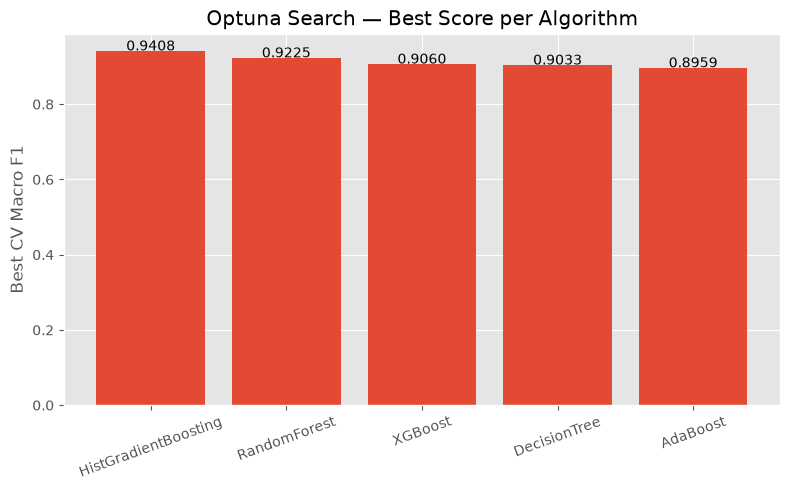

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(algo_best.index, algo_best.values)
plt.ylabel("Best CV Macro F1")
plt.title("Optuna Search — Best Score per Algorithm")
plt.xticks(rotation=20)
for i, v in enumerate(algo_best.values):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "optuna_algorithm_comparison.png", dpi=200)
plt.show()

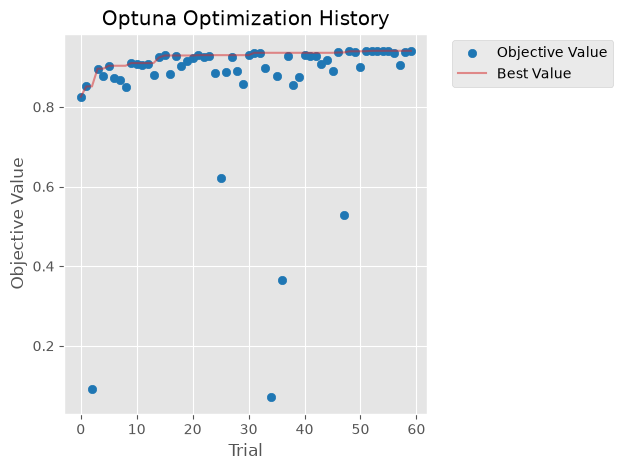

In [30]:
ax = optuna.visualization.matplotlib.plot_optimization_history(study)
ax.set_title("Optuna Optimization History")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "optuna_optimization_history.png", dpi=200, bbox_inches="tight")
plt.show()

In [31]:
TOP_K_ALGOS = 3
top3_algorithms_display = algo_best.head(TOP_K_ALGOS).index.tolist()

reverse_display = {v: k for k, v in ALGO_DISPLAY_NAMES.items()}
top3_algorithms = [reverse_display[name] for name in top3_algorithms_display]

print(f"Top {TOP_K_ALGOS} algorithms selected by Optuna:", top3_algorithms_display)

Top 3 algorithms selected by Optuna: ['HistGradientBoosting', 'RandomForest', 'XGBoost']


In [32]:
best_trial_per_algo = {}

for algo in top3_algorithms:
    subset = completed[completed["params_algorithm"] == algo]
    best_row = subset.loc[subset["value"].idxmax()]
    best_trial_per_algo[algo] = study.trials[int(best_row["number"])]

for algo, trial in best_trial_per_algo.items():
    print(f"{ALGO_DISPLAY_NAMES[algo]} -> CV Macro F1 = {trial.value:.4f}")
    print("   params:", trial.params)

HistGradientBoosting -> CV Macro F1 = 0.9408
   params: {'algorithm': 'hist_gradient_boosting', 'hgb_max_iter': 250, 'hgb_learning_rate': 0.1856048925770564, 'hgb_max_depth': 5, 'hgb_max_leaf_nodes': 38, 'hgb_l2_regularization': 0.9698823525505369}
RandomForest -> CV Macro F1 = 0.9225
   params: {'algorithm': 'random_forest', 'rf_n_estimators': 500, 'rf_max_depth': 30, 'rf_min_samples_split': 3, 'rf_min_samples_leaf': 1, 'rf_max_features': 'log2', 'rf_class_weight': 'balanced'}
XGBoost -> CV Macro F1 = 0.9060
   params: {'algorithm': 'xgboost', 'xgb_n_estimators': 450, 'xgb_max_depth': 7, 'xgb_learning_rate': 0.05550577422563181, 'xgb_subsample': 0.7987037443111942, 'xgb_colsample_bytree': 0.8092432018765922, 'xgb_min_child_weight': 5, 'xgb_gamma': 2.6047899765715274, 'xgb_reg_alpha': 0.0002737535231961718, 'xgb_reg_lambda': 0.0006799175320975557}


## 6. Retrain the Top 3 Models on the Full Training Set

Each selected algorithm is rebuilt with its best hyperparameters and retrained on the **entire**
balanced training set, then evaluated once on the held-out test set.

In [33]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print("="*70)
    print(f"Training {model_name}")
    print("="*70)

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    report_df = pd.DataFrame(
        classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    ).transpose()
    report_df.to_csv(MODELS_PATH / f"{model_name}_classification_report.csv")

    metrics_df = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy],
        "Macro Precision": [precision_macro],
        "Macro Recall": [recall_macro],
        "Macro F1": [macro_f1],
        "Weighted F1": [weighted_f1],
        "Training Time (s)": [train_time],
        "Prediction Time (s)": [pred_time],
    })
    metrics_df.to_csv(MODELS_PATH / f"{model_name}_metrics.csv", index=False)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 10))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
    plt.title(model_name)
    plt.savefig(MODELS_PATH / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.close()

    joblib.dump(model, MODELS_PATH / f"{model_name}.pkl")

    print(metrics_df)
    return metrics_df

In [34]:
final_results = []

for algo, trial in best_trial_per_algo.items():
    model_name = ALGO_DISPLAY_NAMES[algo] + "_Tuned"
    model = instantiate_model(algo, trial.params, n_classes=N_CLASSES, random_state=RANDOM_STATE)

    # persist the winning hyperparameters alongside the model
    with open(MODELS_PATH / f"{model_name}_best_params.json", "w") as f:
        json.dump(trial.params, f, indent=2, default=str)

    metrics = evaluate_model(model, model_name, X_train, y_train, X_test, y_test)
    final_results.append(metrics)

Training HistGradientBoosting_Tuned
                        Model  Accuracy  Macro Precision  Macro Recall  \
0  HistGradientBoosting_Tuned  0.980299         0.878687      0.866418   

   Macro F1  Weighted F1  Training Time (s)  Prediction Time (s)  
0  0.862697     0.982222          25.870349             6.643455  
Training RandomForest_Tuned
                Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  RandomForest_Tuned  0.899091         0.798467      0.861016  0.808213   

   Weighted F1  Training Time (s)  Prediction Time (s)  
0      0.93633          53.981189             4.665916  
Training XGBoost_Tuned
           Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  XGBoost_Tuned   0.98587         0.858577      0.847144  0.842936   

   Weighted F1  Training Time (s)  Prediction Time (s)  
0     0.984632         114.830143             2.424914  


<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

## 7. Final Comparison of the Top 3 Tuned Models

In [35]:
comparison = pd.concat(final_results, ignore_index=True).sort_values(
    "Macro F1", ascending=False
).reset_index(drop=True)

comparison.to_csv(TABLES_PATH / "model_comparison.csv", index=False)
comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Prediction Time (s)
0,HistGradientBoosting_Tuned,0.980299,0.878687,0.866418,0.862697,0.982222,25.870349,6.643455
1,XGBoost_Tuned,0.985870,0.858577,0.847144,0.842936,0.984632,114.830143,2.424914
2,RandomForest_Tuned,0.899091,0.798467,0.861016,0.808213,0.936330,53.981189,4.665916


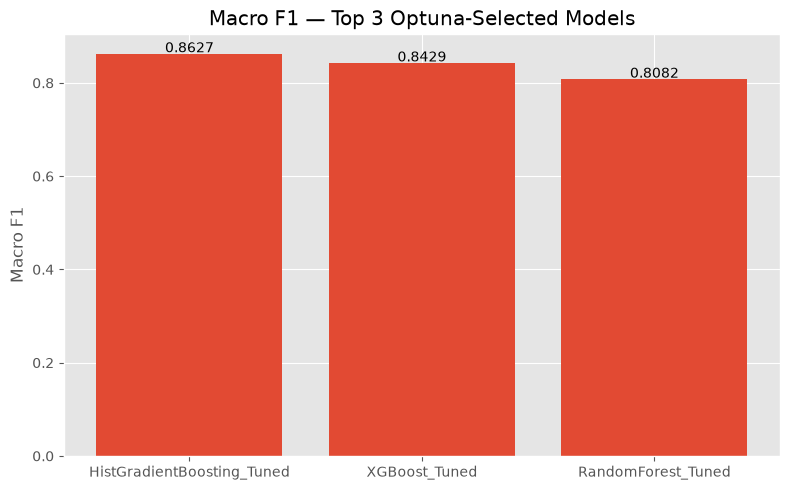

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Macro F1"])
plt.title("Macro F1 — Top 3 Optuna-Selected Models")
plt.ylabel("Macro F1")
for i, v in enumerate(comparison["Macro F1"]):
    plt.text(i, v + 0.003, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "macro_f1_comparison.png", dpi=200)
plt.show()

---
**Outputs (under `Results/`):**
- `Models/optuna_study.pkl` — the full Optuna study (all trials, reusable/resumable)
- `Tables/optuna_trials.csv` — every trial's algorithm, params, and score
- `Models/<Model>_Tuned.pkl`, `_metrics.csv`, `_classification_report.csv`, `_confusion_matrix.png`,
  `_best_params.json` — one set per selected algorithm
- `Tables/model_comparison.csv` — final ranked comparison table

Feed straight into `05_Compare_All_Models.ipynb` for the consolidated report.

In [37]:
train_vs_test_rows = []

for algo, trial in best_trial_per_algo.items():
    model_name = ALGO_DISPLAY_NAMES[algo] + "_Tuned"
    model = joblib.load(MODELS_PATH / f"{model_name}.pkl")

    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_macro_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)

    test_row = comparison[comparison["Model"] == model_name].iloc[0]

    train_vs_test_rows.append({
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_row["Accuracy"],
        "Train Macro F1": train_macro_f1,
        "Test Macro F1": test_row["Macro F1"],
        "Accuracy Gap": train_accuracy - test_row["Accuracy"],
        "Macro F1 Gap": train_macro_f1 - test_row["Macro F1"],
    })

train_vs_test = pd.DataFrame(train_vs_test_rows).sort_values("Accuracy Gap", ascending=False)
train_vs_test.to_csv(TABLES_PATH / "train_vs_test_gap.csv", index=False)

print(train_vs_test)

for _, row in train_vs_test.iterrows():
    if row["Accuracy Gap"] > 0.05:
        print(f"\nNote: {row['Model']} shows a notable train/test gap ({row['Accuracy Gap']:.4f}) — possible overfitting.")

                        Model  Train Accuracy  Test Accuracy  Train Macro F1  \
1          RandomForest_Tuned        0.969477       0.899091        0.967747   
0  HistGradientBoosting_Tuned        0.976146       0.980299        0.964668   
2               XGBoost_Tuned        0.971134       0.985870        0.942379   

   Test Macro F1  Accuracy Gap  Macro F1 Gap  
1       0.808213      0.070386      0.159534  
0       0.862697     -0.004153      0.101970  
2       0.842936     -0.014737      0.099443  

Note: RandomForest_Tuned shows a notable train/test gap (0.0704) — possible overfitting.
